- Nate Diaz-Santana
- Applied Data Science

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

from lightgbm import LGBMRegressor
from scipy.sparse import hstack, csr_matrix

# Modeling Steam Game Prices for Indie Developers

## Data Import & Preparation

In [5]:
data = pd.read_csv("a_steam_data_2021_2025.csv")

data.head()

,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
0,3057270,Seafarer's Gambit,2024,"Jul 5, 2024",Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios
1,3822840,Capitalist Misadventures,2025,"Jul 25, 2025",Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios
2,3216640,The Beast and the Princess,2025,"Jun 17, 2025",Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controll...,12.99,0,Libragames,Libragames
3,2403620,Air Twister,2023,"Nov 10, 2023",Action;Adventure;Indie,Single-player;Steam Achievements;Full controll...,24.99,0,YS Net,ININ
4,1538040,Horde Slayer,2021,"Mar 19, 2021",Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controll...,3.99,0,Wagner Rodrigues,Wagner Rodrigues


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65521 entries, 0 to 65520
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            65521 non-null  int64  
 1   name             65521 non-null  object 
 2   release_year     65521 non-null  int64  
 3   release_date     65521 non-null  object 
 4   genres           65455 non-null  object 
 5   categories       65514 non-null  object 
 6   price            65521 non-null  float64
 7   recommendations  65521 non-null  int64  
 8   developer        65468 non-null  object 
 9   publisher        65338 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 5.0+ MB


In [7]:
data.describe()

,appid,release_year,price,recommendations
count,6.552100e+04,65521.000000,65521.000000,65521.000000
mean,2.580607e+06,2023.453091,7.204043,362.165336
std,7.692480e+05,1.386641,16.914429,6936.837198
min,1.200220e+06,2021.000000,0.000000,0.000000
25%,1.916970e+06,2022.000000,0.990000,0.000000
50%,2.516050e+06,2024.000000,3.990000,0.000000
75%,3.193800e+06,2025.000000,9.740000,0.000000
max,4.243930e+06,2025.000000,1900.000000,862487.000000


In [8]:
data.isna().sum()

appid                0
name                 0
release_year         0
release_date         0
genres              66
categories           7
price                0
recommendations      0
developer           53
publisher          183
dtype: int64

In [9]:
data = data.drop(columns={'appid'}, axis=1)

In [10]:
data[data["price"] <= 100]["price"].describe()

count    65294.000000
mean         6.476904
std          8.198899
min          0.000000
25%          0.990000
50%          3.990000
75%          8.990000
max         99.990000
Name: price, dtype: float64

In [11]:
data = data[data["price"] <= 100].reset_index(drop=True)

In [12]:
data["genres"] = data["genres"].fillna("")
data["categories"] = data["categories"].fillna("")
data["publisher"] = data["publisher"].fillna("Unknown")

In [13]:
data["genres"] = data["genres"].str.split(";")
data["categories"] = data["categories"].str.split(";")

In [14]:
data.head()

,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
0,Seafarer's Gambit,2024,"Jul 5, 2024","[Action, Adventure, Indie, RPG, Strategy]","[Single-player, Family Sharing]",3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios
1,Capitalist Misadventures,2025,"Jul 25, 2025","[Casual, Indie, Simulation, Strategy]","[Single-player, Save Anytime, Family Sharing]",7.99,0,Caramelo Studios,Caramelo Studios
2,The Beast and the Princess,2025,"Jun 17, 2025","[Adventure, Indie, Strategy]","[Single-player, Steam Achievements, Full contr...",12.99,0,Libragames,Libragames
3,Air Twister,2023,"Nov 10, 2023","[Action, Adventure, Indie]","[Single-player, Steam Achievements, Full contr...",24.99,0,YS Net,ININ
4,Horde Slayer,2021,"Mar 19, 2021","[Action, Adventure, Casual, Indie, RPG, Early ...","[Single-player, Steam Achievements, Full contr...",3.99,0,Wagner Rodrigues,Wagner Rodrigues


## EDA

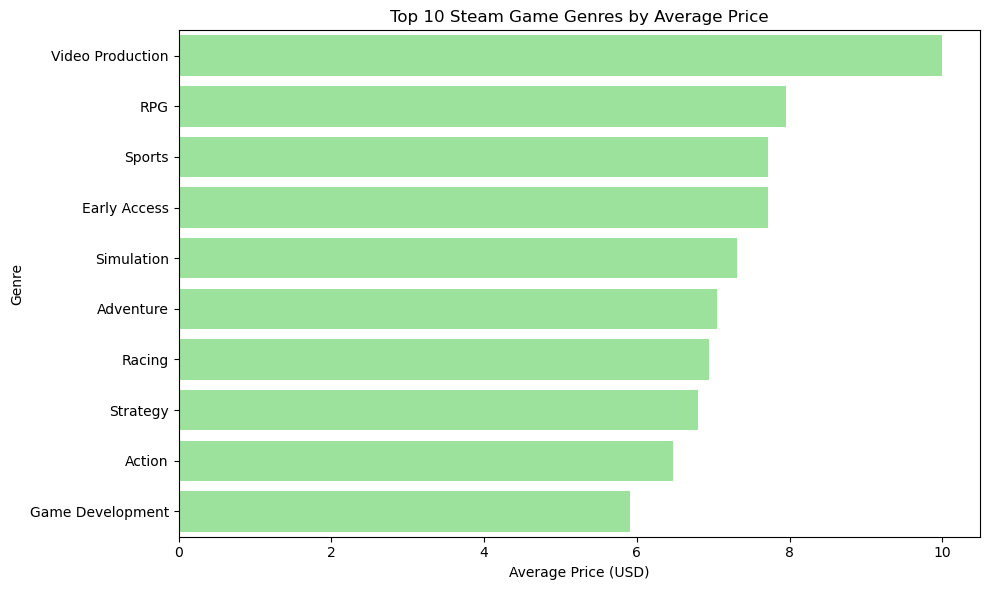

In [16]:
genres_exploded = data.explode('genres')
avg_price_by_genre = genres_exploded.groupby('genres')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sb.barplot(x=avg_price_by_genre.values, y=avg_price_by_genre.index, color='lightgreen')
plt.xlabel("Average Price (USD)")
plt.ylabel("Genre")
plt.title("Top 10 Steam Game Genres by Average Price")
plt.tight_layout()
plt.show()

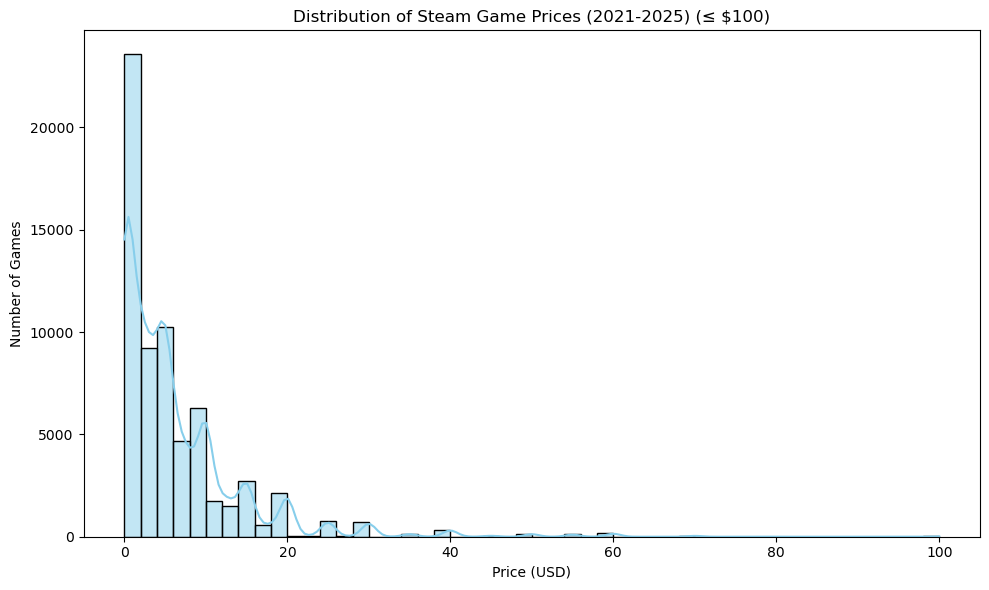

In [17]:
plt.figure(figsize=(10,6))
sb.histplot(data['price'], bins=50, kde=True, color='skyblue')
plt.xlabel("Price (USD)")
plt.ylabel("Number of Games")
plt.title("Distribution of Steam Game Prices (2021-2025) (≤ $100)")
plt.tight_layout()
plt.show()

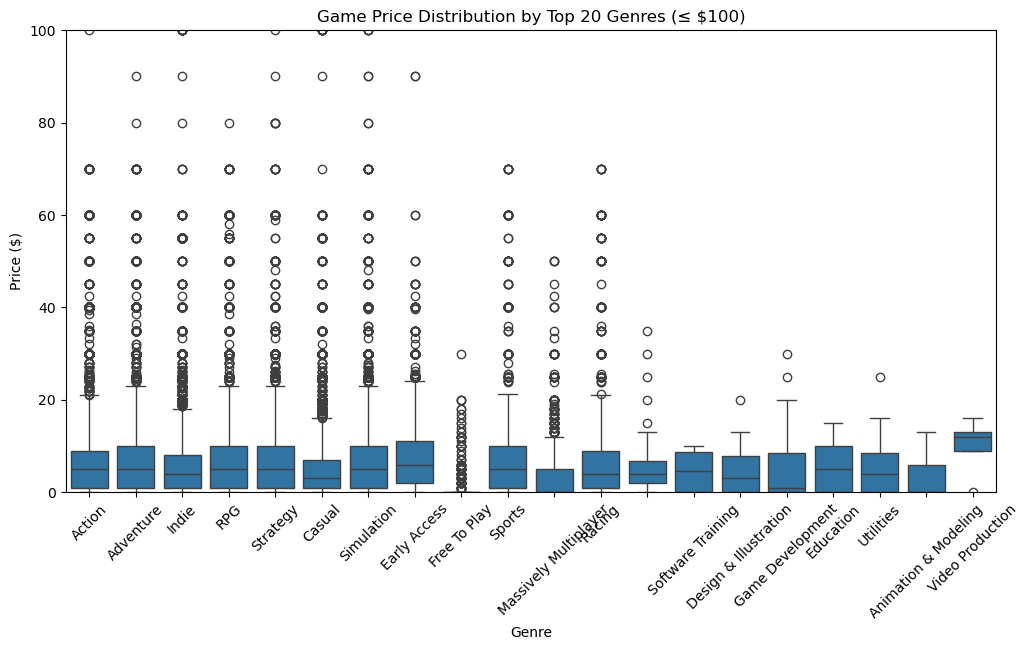

In [18]:
top_genres = genres_exploded['genres'].value_counts().nlargest(20).index
genres_top20 = genres_exploded[genres_exploded['genres'].isin(top_genres)]

plt.figure(figsize=(12,6))
sb.boxplot(x='genres', y='price', data=genres_top20)
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.title("Game Price Distribution by Top 20 Genres (≤ $100)")
plt.xlabel("Genre")
plt.ylabel("Price ($)")
plt.show()

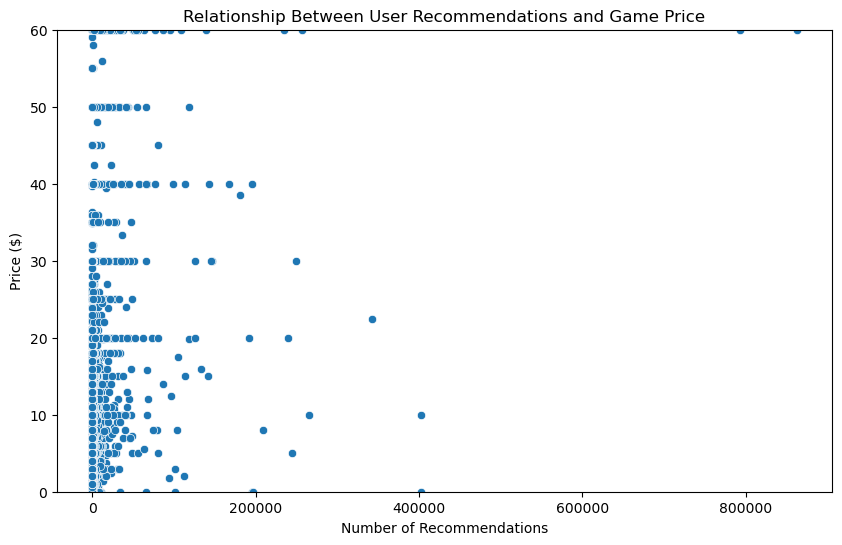

In [19]:
plt.figure(figsize=(10,6))
sb.scatterplot(x='recommendations', y='price', data=data)
plt.ylim(0, 60)
plt.title("Relationship Between User Recommendations and Game Price")
plt.xlabel("Number of Recommendations")
plt.ylabel("Price ($)")
plt.show()

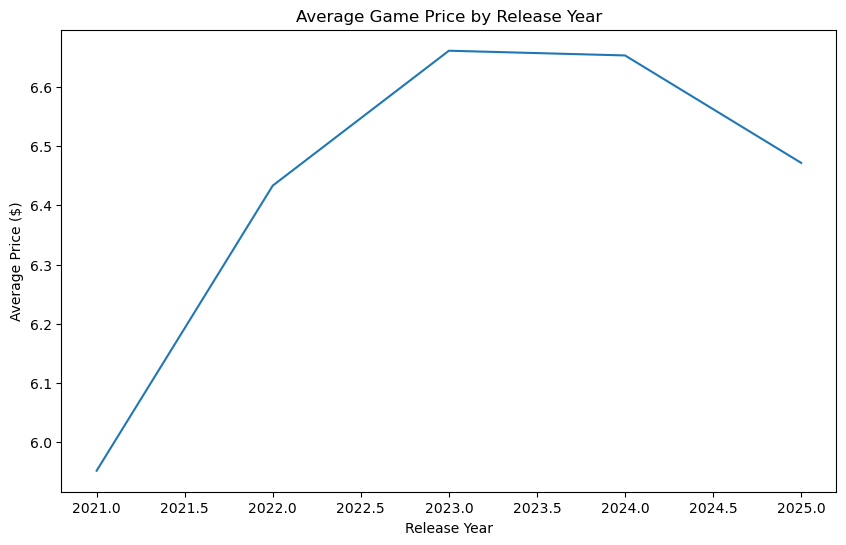

In [20]:
avg_price_year = data.groupby('release_year')['price'].mean().reset_index()

plt.figure(figsize=(10,6))
sb.lineplot(x='release_year', y='price', data=avg_price_year)
plt.title("Average Game Price by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Price ($)")
plt.show()

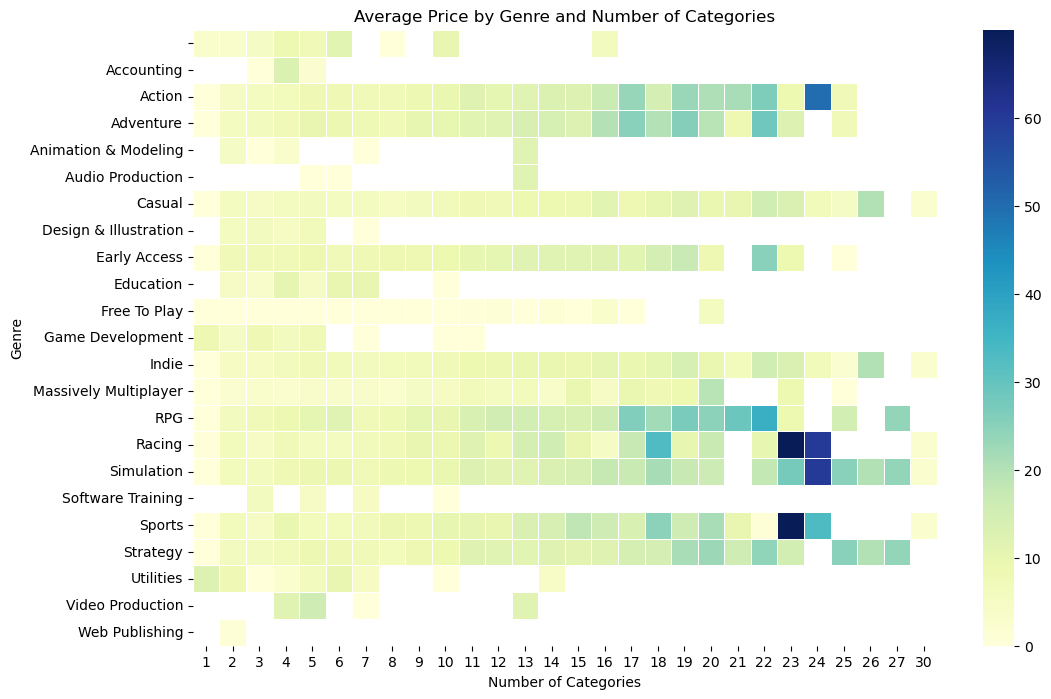

In [21]:
data_exploded = data.copy()
data_exploded = data_exploded.explode('genres')

data_exploded['num_categories'] = data_exploded['categories'].fillna('').astype(str).str.count(',') + 1

pivot = data_exploded.pivot_table(
    index='genres',
    columns='num_categories',
    values='price',
    aggfunc='mean'
)

pivot = pivot.dropna(how='all').dropna(axis=1, how='all')

plt.figure(figsize=(12,8))
sb.heatmap(pivot, cmap="YlGnBu", linewidths=0.5)
plt.title("Average Price by Genre and Number of Categories")
plt.xlabel("Number of Categories")
plt.ylabel("Genre")
plt.show()

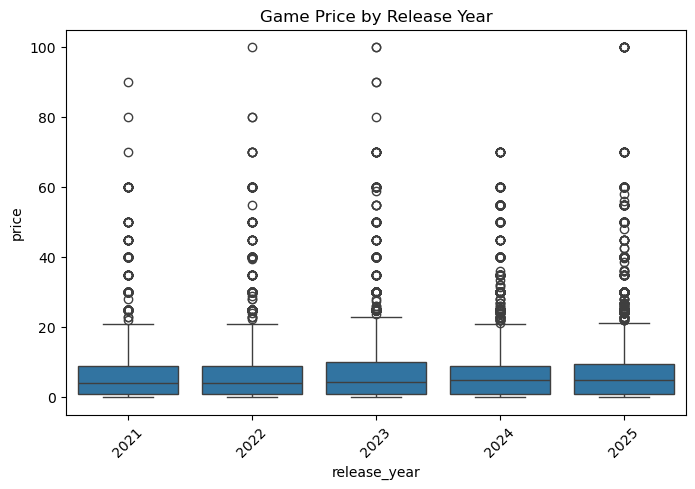

In [22]:
plt.figure(figsize=(8,5))
sb.boxplot(x="release_year", y="price", data=data)
plt.title("Game Price by Release Year")
plt.xticks(rotation=45)
plt.show()

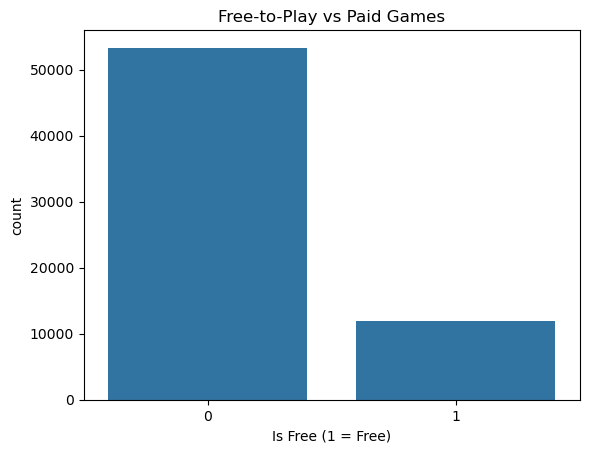

In [23]:
data["is_free"] = (data["price"] == 0).astype(int)

sb.countplot(x="is_free", data=data)
plt.title("Free-to-Play vs Paid Games")
plt.xlabel("Is Free (1 = Free)")
plt.show()

## Modeling

### Data Pre-processing

In [26]:
data[data["price"] <= 70]["price"].describe()

count    65271.000000
mean         6.445638
std          8.028030
min          0.000000
25%          0.990000
50%          3.990000
75%          8.990000
max         69.990000
Name: price, dtype: float64

In [27]:
data = data[data["price"] <= 70].reset_index(drop=True)

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65271 entries, 0 to 65270
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             65271 non-null  object 
 1   release_year     65271 non-null  int64  
 2   release_date     65271 non-null  object 
 3   genres           65271 non-null  object 
 4   categories       65271 non-null  object 
 5   price            65271 non-null  float64
 6   recommendations  65271 non-null  int64  
 7   developer        65218 non-null  object 
 8   publisher        65271 non-null  object 
 9   is_free          65271 non-null  int32  
dtypes: float64(1), int32(1), int64(2), object(6)
memory usage: 4.7+ MB


In [29]:
data['num_genres'] = data['genres'].apply(len)
data['num_categories'] = data['categories'].apply(len)

In [30]:
data['release_date'] = pd.to_datetime(data['release_date'], errors='coerce')

data['release_month'] = data['release_date'].dt.month
data['release_month'] = data['release_month'].fillna(0).astype(int)

In [31]:
def month_to_season(m):
    if m in [12,1,2]:
        return 0  # Winter
    elif m in [3,4,5]:
        return 1  # Spring
    elif m in [6,7,8]:
        return 2  # Summer
    elif m in [9,10,11]:
        return 3  # Fall
    else:
        return 4  # Unknown

data['release_season'] = data['release_month'].apply(month_to_season)

In [32]:
publisher_counts = data['publisher'].value_counts()
rare_publishers = publisher_counts[publisher_counts < 10].index
data['publisher'] = data['publisher'].replace(rare_publishers, 'Other')

In [33]:
data.head()

,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher,is_free,num_genres,num_categories,release_month,release_season
0,Seafarer's Gambit,2024,2024-07-05,"[Action, Adventure, Indie, RPG, Strategy]","[Single-player, Family Sharing]",3.99,0,Bouncy Rocket Studios,Other,0,5,2,7,2
1,Capitalist Misadventures,2025,2025-07-25,"[Casual, Indie, Simulation, Strategy]","[Single-player, Save Anytime, Family Sharing]",7.99,0,Caramelo Studios,Other,0,4,3,7,2
2,The Beast and the Princess,2025,2025-06-17,"[Adventure, Indie, Strategy]","[Single-player, Steam Achievements, Full contr...",12.99,0,Libragames,Other,0,3,9,6,2
3,Air Twister,2023,2023-11-10,"[Action, Adventure, Indie]","[Single-player, Steam Achievements, Full contr...",24.99,0,YS Net,Other,0,3,5,11,3
4,Horde Slayer,2021,2021-03-19,"[Action, Adventure, Casual, Indie, RPG, Early ...","[Single-player, Steam Achievements, Full contr...",3.99,0,Wagner Rodrigues,Other,0,6,5,3,1


### Data Encoding

In [35]:
mlb_genres = MultiLabelBinarizer()
mlb_categories = MultiLabelBinarizer()

genres_sparse = csr_matrix(mlb_genres.fit_transform(data["genres"]))

categories_sparse = csr_matrix(mlb_categories.fit_transform(data["categories"]))

year_sparse = csr_matrix(data[["release_year"]].values.astype(np.float32))

recs_sparse = csr_matrix(data[["recommendations"]].values.astype(np.float32))

num_features_sparse = csr_matrix(data[['num_genres', 'num_categories', 'release_month', 'release_season']].values.astype(np.float32))

### Modeling Function

In [37]:
def evaluate_models(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {
        "Ridge Regression": Ridge(
            alpha=1.0,
            solver="sparse_cg",
            random_state=42
        ),
        "Random Forest": RandomForestRegressor(
            n_estimators=300,
            max_depth=15,          # limits overfitting
            min_samples_leaf=5,    # 5 samples per leaf
            random_state=42,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            random_state=42
        ),
        "LightGBM": LGBMRegressor(
            n_estimators=500,        
            learning_rate=0.05,      
            max_depth=-1,            
            num_leaves=50,
            min_child_samples=40,    
            colsample_bytree=0.8,    # feature subsampling
            random_state=42,
            n_jobs=-1
        )
    }

    results = []
    trained_models = {}

    for name, model in models.items():
        print(f"Training {name} ({title})...")
        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        mae = mean_absolute_error(y_test, preds)
        rmse = root_mean_squared_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        mape = np.mean(np.abs((y_test - preds) / np.maximum(y_test, 1))) * 100

        results.append({
            "Model": name,
            "MAE ($)": mae,
            "RMSE ($)": rmse,
            "R²": r2,
            "MAPE (%)": mape
        })

        trained_models[name] = model

    results_df = pd.DataFrame(results).sort_values("MAE ($)")

    return {
        "results": results_df,
        "models": trained_models,
        "X_test": X_test,
        "y_test": y_test,
        "X_train": X_train,
        "y_train": y_train
    }

## 1st Model Group - No Publisher or Self-Published

In [39]:
X_no_publisher = hstack([
    genres_sparse,
    categories_sparse,
    num_features_sparse
]).astype("float32")

y = data['price'].values

eval_no_publisher = evaluate_models(X_no_publisher, y, "No Publisher")

print("\nSELF-PUBLISHED / FIRST-TIME PUBLISHING MODEL RESULTS (with numerical features)")
print(eval_no_publisher['results'])

Training Ridge Regression (No Publisher)...
Training Random Forest (No Publisher)...
Training Gradient Boosting (No Publisher)...
Training LightGBM (No Publisher)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 180
[LightGBM] [Info] Number of data points in the train set: 52216, number of used features: 66
[LightGBM] [Info] Start training from score 6.458947

SELF-PUBLISHED / FIRST-TIME PUBLISHING MODEL RESULTS (with numerical features)
               Model   MAE ($)  RMSE ($)        R²    MAPE (%)
1      Random Forest  3.829937  6.404457  0.349751  108.715271
3           LightGBM  3.875049  6.359019  0.358945  114.261981
2  Gradient Boosting  4.026056  6.537091  0.322539  124.746051
0   Ridge Regression  4.369505  6.861786  0.253570  152.334881


## 2nd Model Group - With Publisher

In [41]:
ohe_pub = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

publisher_sparse = ohe_pub.fit_transform(
    data[["publisher"]]
)

X_with_publisher = hstack([
    genres_sparse,
    categories_sparse,
    publisher_sparse,
    year_sparse,
    recs_sparse
]).astype("float32")

eval_publisher = evaluate_models(X_with_publisher, y, "With Publisher")

print("\nPUBLISHER-AWARE MODEL RESULTS")
print(eval_publisher["results"])

Training Ridge Regression (With Publisher)...
Training Random Forest (With Publisher)...
Training Gradient Boosting (With Publisher)...
Training LightGBM (With Publisher)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002240 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 461
[LightGBM] [Info] Number of data points in the train set: 52216, number of used features: 102
[LightGBM] [Info] Start training from score 6.458947

PUBLISHER-AWARE MODEL RESULTS
               Model   MAE ($)  RMSE ($)        R²    MAPE (%)
1      Random Forest  3.642319  6.024077  0.424698  110.178929
3           LightGBM  3.662304  6.073029  0.415310  111.321136
2  Gradient Boosting  3.750819  6.045794  0.420543  120.914775
0   Ridge Regression  4.485470  7.007314  0.221573  159.875282


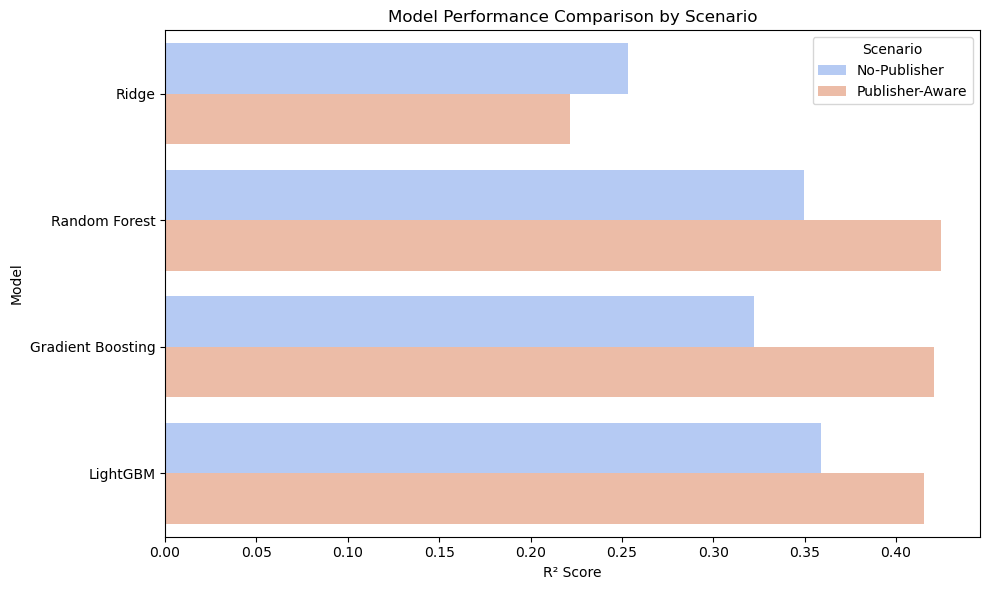

In [42]:
model_perf = pd.DataFrame({
    'Model': ['Ridge', 'Random Forest', 'Gradient Boosting', 'LightGBM']*2,
    'Scenario': ['No-Publisher']*4 + ['Publisher-Aware']*4,
    'MAE': [4.369505, 3.829937, 4.026056, 3.875049, 4.485470, 3.642319, 3.750819, 3.662304],
    'RMSE': [6.861786, 6.404457, 6.537091, 6.359019, 7.007314, 6.024077, 6.045794, 6.073029],
    'R2': [0.253570, 0.349751, 0.322539, 0.358945, 0.221573, 0.424698, 0.420543, 0.415310]
})

plt.figure(figsize=(10,6))
sb.barplot(x='R2', y='Model', hue='Scenario', data=model_perf, palette='coolwarm')
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.title("Model Performance Comparison by Scenario")
plt.legend(title="Scenario")
plt.tight_layout()
plt.show()

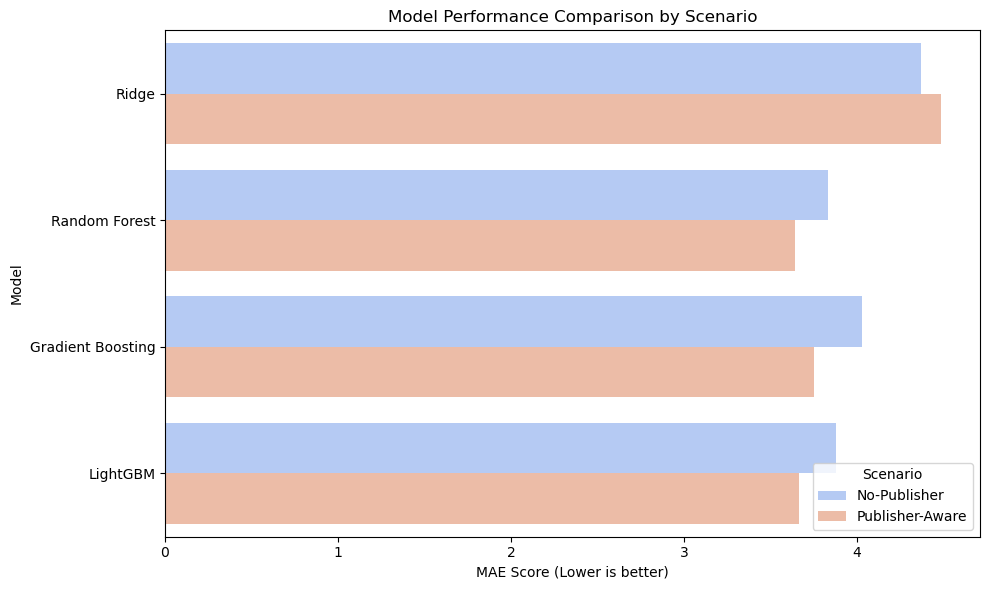

In [43]:
model_perf = pd.DataFrame({
    'Model': ['Ridge', 'Random Forest', 'Gradient Boosting', 'LightGBM']*2,
    'Scenario': ['No-Publisher']*4 + ['Publisher-Aware']*4,
    'MAE': [4.369505, 3.829937, 4.026056, 3.875049, 4.485470, 3.642319, 3.750819, 3.662304],
    'RMSE': [6.861786, 6.404457, 6.537091, 6.359019, 7.007314, 6.024077, 6.045794, 6.073029],
    'R2': [0.253570, 0.349751, 0.322539, 0.358945, 0.221573, 0.424698, 0.420543, 0.415310]
})

plt.figure(figsize=(10,6))
sb.barplot(x='MAE', y='Model', hue='Scenario', data=model_perf, palette='coolwarm')
plt.xlabel("MAE Score (Lower is better)")
plt.ylabel("Model")
plt.title("Model Performance Comparison by Scenario")
plt.legend(title="Scenario")
plt.tight_layout()
plt.show()